# Problem Statement

Road accidents are influenced by multiple factors such as junction type, road type, speed limit, lighting conditions, weather, road-surface conditions, number of vehicles, and time of occurrence. Understanding how these factors relate to accident severity can help identify conditions associated with more serious accidents.

The objective of this project is to analyze historical road accident data and identify the key factors associated with accident severity. Furthermore, a machine learning model can be developed to predict the severity of an accident (Minor, Major, etc.) based on road, traffic, environmental, and vehicle-related conditions


# Objective

To develop a data-driven system that analyzes road accident characteristics and predicts accident severity using factors such as junction conditions, road type, speed limit, lighting, weather, road surface, time, number of vehicles, and vehicle type.


In [ ]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Reading the dataset into goggle colab
data= pd.read_csv("Accident dataset.csv")

In [ ]:
# Read the number of rows and columns
data.shape

(50008, 20)

In [ ]:
# Fetch the first 5 rows
data.head()

,Accident_Index,Accident Date,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,Longitude,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,1,01-10-2022,Auto traffic signal,T or staggered junction,Minor,51.485108,Daylight,Hamar Jajab,NaN,-0.373240,2,2,Metropolitan Police,Wet or damp,Single carriageway,30,0.572917,Urban,Raining no high winds,Car
1,2,06-07-2022,Auto traffic signal,Crossroads,Minor,51.481508,Darkness - lights lit,Hamar Jajab,NaN,-0.347301,2,2,Metropolitan Police,Dry,Single carriageway,30,0.959722,Urban,Fine no high winds,Car
2,3,08-07-2022,Auto traffic signal,Crossroads,Minor,51.483206,Daylight,Hamar Jajab,NaN,-0.327508,1,2,Metropolitan Police,Dry,Dual carriageway,40,0.309028,Urban,Fine no high winds,Bus or coach (17 or more pass seats)
3,4,21-09-2022,Auto traffic signal,T or staggered junction,Major,51.446757,Daylight,Hamar Jajab,NaN,-0.409430,1,2,Metropolitan Police,Dry,Single carriageway,30,0.380556,Urban,Fine no high winds,Bus or coach (17 or more pass seats)
4,5,03-10-2022,Data missing or out of range,Not at junction or within 20 metres,Minor,51.435504,Darkness - lights lit,Hamar Jajab,NaN,-0.382197,1,2,Metropolitan Police,Wet or damp,Dual carriageway,50,0.125000,Urban,Raining no high winds,Car


In [ ]:
# Fetch the last five rows
data.tail()

,Accident_Index,Accident Date,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,Longitude,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
50003,49996,02-03-2024,Data missing or out of range,Not at junction or within 20 metres,Minor,52.615092,Daylight,Waberi,NaN,-1.698813,1,1,Staffordshire,Dry,Dual carriageway,30,0.375000,Urban,Fine no high winds,Car
50004,49997,26-02-2024,Give way or uncontrolled,Private drive or entrance,Minor,52.563513,Daylight,Waberi,NaN,-2.252675,1,3,Staffordshire,Wet or damp,Single carriageway,50,0.604167,Rural,Fine no high winds,Car
50005,49998,28-02-2024,Give way or uncontrolled,T or staggered junction,Minor,52.667873,Darkness - lights lit,Waberi,NaN,-2.056307,2,2,Staffordshire,Dry,Single carriageway,50,0.777778,Rural,Fine no high winds,Car
50006,49999,22-02-2024,Give way or uncontrolled,T or staggered junction,Minor,52.667873,Darkness - lights lit,Waberi,NaN,-2.056307,2,2,Staffordshire,Dry,Single carriageway,50,0.777778,Rural,Fine no high winds,Car
50007,50000,28-02-2024,Give way or uncontrolled,T or staggered junction,Minor,52.667873,Darkness - lights lit,Waberi,NaN,-2.056307,2,2,Staffordshire,Dry,Single carriageway,50,0.777778,Rural,Fine no high winds,Car


In [ ]:
# Return the statistical report of all numerical columns
data.describe()

,Accident_Index,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles,Speed_limit,Time
count,50008.000000,50008.000000,50008.000000,50008.000000,50008.000000,50008.000000,50008.000000
mean,24996.501920,53.380897,-1.724230,1.401336,1.834247,36.522756,0.586183
std,14436.207144,0.958238,0.858474,0.887915,0.712089,12.654897,0.209338
min,1.000000,51.297642,-3.596994,1.000000,1.000000,20.000000,0.000694
25%,12494.750000,52.692599,-2.330074,1.000000,1.000000,30.000000,0.437500
50%,24996.500000,53.526394,-1.784743,1.000000,2.000000,30.000000,0.614583
75%,37498.250000,53.808947,-1.338762,2.000000,2.000000,40.000000,0.736111
max,50000.000000,55.806130,0.095160,40.000000,19.000000,70.000000,0.999306


In [ ]:
# Returns the information such as column name , non null count , dtype
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50008 entries, 0 to 50007
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Accident_Index              50008 non-null  int64  
 1   Accident Date               50008 non-null  object 
 2   Junction_Control            50008 non-null  object 
 3   Junction_Detail             50008 non-null  object 
 4   Accident_Severity           50006 non-null  object 
 5   Latitude                    50008 non-null  float64
 6   Light_Conditions            50008 non-null  object 
 7   Local_Authority_(District)  50008 non-null  object 
 8   Carriageway_Hazards         688 non-null    object 
 9   Longitude                   50008 non-null  float64
 10  Number_of_Casualties        50008 non-null  int64  
 11  Number_of_Vehicles          50008 non-null  int64  
 12  Police_Force                50008 non-null  object 
 13  Road_Surface_Conditions     500

In [ ]:
# Returns the datatype of each column
data.dtypes

,0
Accident_Index,int64
Accident Date,object
Junction_Control,object
Junction_Detail,object
Accident_Severity,object
Latitude,float64
Light_Conditions,object
Local_Authority_(District),object
Carriageway_Hazards,object
Longitude,float64


In [ ]:
# Returns all the columns
data.columns

Index(['Accident_Index', 'Accident Date', 'Junction_Control',
       'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Carriageway_Hazards', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type'],
      dtype='object')

In [ ]:
summary = pd.DataFrame({
    'Unique_Values': data.nunique(dropna=False),
    'Unique_Names': data.apply(lambda x: x.unique())
})

print(summary)

                            Unique_Values  \
Accident_Index                      50000   
Accident Date                        1066   
Junction_Control                        7   
Junction_Detail                         9   
Accident_Severity                       5   
Latitude                            45997   
Light_Conditions                        5   
Local_Authority_(District)              7   
Carriageway_Hazards                     6   
Longitude                           46485   
Number_of_Casualties                   19   
Number_of_Vehicles                     15   
Police_Force                           15   
Road_Surface_Conditions                 5   
Road_Type                               6   
Speed_limit                             6   
Time                                 1421   
Urban_or_Rural_Area                     3   
Weather_Conditions                      8   
Vehicle_Type                           15   

                                                      

# Checking the missing or null values

In [ ]:
# Returns the number of missing values present in each column
data.isnull().sum()

,0
Accident_Index,0
Accident Date,0
Junction_Control,0
Junction_Detail,0
Accident_Severity,2
Latitude,0
Light_Conditions,0
Local_Authority_(District),0
Carriageway_Hazards,49320
Longitude,0


# Checking the duplicates

In [ ]:
# Returns the number of duplicate values
data.duplicated().sum()

np.int64(0)

# Droping duplicates

In [ ]:
# Dropping the duplicate values
data= data.drop_duplicates().reset_index(drop=True)

In [ ]:
# Checking if duplicate values are present
data.duplicated().sum()

np.int64(0)

# Filled the missing values with mode value of this column

In [ ]:

data['Urban_or_Rural_Area'].mode()[0]

'Urban'

In [ ]:
data['Urban_or_Rural_Area'] = data['Urban_or_Rural_Area'].fillna(data['Urban_or_Rural_Area'].mode()[0])

In [ ]:
data['Accident_Severity']

,Accident_Severity
0,Minor
1,Minor
2,Minor
3,Major
4,Minor
...,...
49995,Minor
49996,Minor
49997,Minor
49998,Minor


# Dropped Carriageway_Hazards column since it contains more then 90 percent of null values

In [ ]:
data.drop(columns=['Carriageway_Hazards'] ,inplace=True)

In [ ]:
data['Accident_Severity']=data['Accident_Severity'].fillna(data['Accident_Severity'].mode()[0])

In [ ]:
data.isnull().sum()

,0
Accident_Index,0
Accident Date,0
Junction_Control,0
Junction_Detail,0
Accident_Severity,0
Latitude,0
Light_Conditions,0
Local_Authority_(District),0
Longitude,0
Number_of_Casualties,0


In [ ]:
data

,Accident_Index,Accident Date,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,1,01-10-2022,Auto traffic signal,T or staggered junction,Minor,51.485108,Daylight,Hamar Jajab,-0.373240,2,2,Metropolitan Police,Wet or damp,Single carriageway,30,0.572917,Urban,Raining no high winds,Car
1,2,06-07-2022,Auto traffic signal,Crossroads,Minor,51.481508,Darkness - lights lit,Hamar Jajab,-0.347301,2,2,Metropolitan Police,Dry,Single carriageway,30,0.959722,Urban,Fine no high winds,Car
2,3,08-07-2022,Auto traffic signal,Crossroads,Minor,51.483206,Daylight,Hamar Jajab,-0.327508,1,2,Metropolitan Police,Dry,Dual carriageway,40,0.309028,Urban,Fine no high winds,Bus or coach (17 or more pass seats)
3,4,21-09-2022,Auto traffic signal,T or staggered junction,Major,51.446757,Daylight,Hamar Jajab,-0.409430,1,2,Metropolitan Police,Dry,Single carriageway,30,0.380556,Urban,Fine no high winds,Bus or coach (17 or more pass seats)
4,5,03-10-2022,Data missing or out of range,Not at junction or within 20 metres,Minor,51.435504,Darkness - lights lit,Hamar Jajab,-0.382197,1,2,Metropolitan Police,Wet or damp,Dual carriageway,50,0.125000,Urban,Raining no high winds,Car
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,02-03-2024,Data missing or out of range,Not at junction or within 20 metres,Minor,52.615092,Daylight,Waberi,-1.698813,1,1,Staffordshire,Dry,Dual carriageway,30,0.375000,Urban,Fine no high winds,Car
49996,49997,26-02-2024,Give way or uncontrolled,Private drive or entrance,Minor,52.563513,Daylight,Waberi,-2.252675,1,3,Staffordshire,Wet or damp,Single carriageway,50,0.604167,Rural,Fine no high winds,Car
49997,49998,28-02-2024,Give way or uncontrolled,T or staggered junction,Minor,52.667873,Darkness - lights lit,Waberi,-2.056307,2,2,Staffordshire,Dry,Single carriageway,50,0.777778,Rural,Fine no high winds,Car
49998,49999,22-02-2024,Give way or uncontrolled,T or staggered junction,Minor,52.667873,Darkness - lights lit,Waberi,-2.056307,2,2,Staffordshire,Dry,Single carriageway,50,0.777778,Rural,Fine no high winds,Car


In [ ]:
# Rounding the values to 2 decimal places
data['Latitude']=data['Latitude'].round(2)

In [ ]:
# Rounding the values to 2 decimal values
data['Longitude']=data['Longitude'].round(2)

In [ ]:
#  Returns the columns of type float and integer
data.select_dtypes(include=['Int64','float64'])

,Accident_Index,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles,Speed_limit,Time
0,1,51.49,-0.37,2,2,30,0.572917
1,2,51.48,-0.35,2,2,30,0.959722
2,3,51.48,-0.33,1,2,40,0.309028
3,4,51.45,-0.41,1,2,30,0.380556
4,5,51.44,-0.38,1,2,50,0.125000
...,...,...,...,...,...,...,...
49995,49996,52.62,-1.70,1,1,30,0.375000
49996,49997,52.56,-2.25,1,3,50,0.604167
49997,49998,52.67,-2.06,2,2,50,0.777778
49998,49999,52.67,-2.06,2,2,50,0.777778


In [ ]:
# Converting time to standard days and minutes
data['Time'] = pd.to_timedelta(data['Time'], unit='D')

In [ ]:
data['Time']

,Time
0,0 days 13:45:00.000028800
1,0 days 23:01:59.999980800
2,0 days 07:25:00.000019199
3,0 days 09:08:00.000038400
4,0 days 03:00:00
...,...
49995,0 days 09:00:00
49996,0 days 14:30:00.000028800
49997,0 days 18:40:00.000019200
49998,0 days 18:40:00.000019200


In [ ]:
data['Hour'] = data['Time'].dt.total_seconds() // 3600

In [ ]:
data['Hour']

,Hour
0,13.0
1,23.0
2,7.0
3,9.0
4,3.0
...,...
49995,9.0
49996,14.0
49997,18.0
49998,18.0


In [ ]:
# Dropping the time column
data.drop(columns='Time')

,Accident_Index,Accident Date,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Hour
0,1,01-10-2022,Auto traffic signal,T or staggered junction,Minor,51.49,Daylight,Hamar Jajab,-0.37,2,2,Metropolitan Police,Wet or damp,Single carriageway,30,Urban,Raining no high winds,Car,13.0
1,2,06-07-2022,Auto traffic signal,Crossroads,Minor,51.48,Darkness - lights lit,Hamar Jajab,-0.35,2,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Car,23.0
2,3,08-07-2022,Auto traffic signal,Crossroads,Minor,51.48,Daylight,Hamar Jajab,-0.33,1,2,Metropolitan Police,Dry,Dual carriageway,40,Urban,Fine no high winds,Bus or coach (17 or more pass seats),7.0
3,4,21-09-2022,Auto traffic signal,T or staggered junction,Major,51.45,Daylight,Hamar Jajab,-0.41,1,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Bus or coach (17 or more pass seats),9.0
4,5,03-10-2022,Data missing or out of range,Not at junction or within 20 metres,Minor,51.44,Darkness - lights lit,Hamar Jajab,-0.38,1,2,Metropolitan Police,Wet or damp,Dual carriageway,50,Urban,Raining no high winds,Car,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,02-03-2024,Data missing or out of range,Not at junction or within 20 metres,Minor,52.62,Daylight,Waberi,-1.70,1,1,Staffordshire,Dry,Dual carriageway,30,Urban,Fine no high winds,Car,9.0
49996,49997,26-02-2024,Give way or uncontrolled,Private drive or entrance,Minor,52.56,Daylight,Waberi,-2.25,1,3,Staffordshire,Wet or damp,Single carriageway,50,Rural,Fine no high winds,Car,14.0
49997,49998,28-02-2024,Give way or uncontrolled,T or staggered junction,Minor,52.67,Darkness - lights lit,Waberi,-2.06,2,2,Staffordshire,Dry,Single carriageway,50,Rural,Fine no high winds,Car,18.0
49998,49999,22-02-2024,Give way or uncontrolled,T or staggered junction,Minor,52.67,Darkness - lights lit,Waberi,-2.06,2,2,Staffordshire,Dry,Single carriageway,50,Rural,Fine no high winds,Car,18.0


In [ ]:
data.drop(columns=['Time'],inplace=True)

In [ ]:
data.rename(columns={'Hour':'Time'})

,Accident_Index,Accident Date,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Time
0,1,01-10-2022,Auto traffic signal,T or staggered junction,Minor,51.49,Daylight,Hamar Jajab,-0.37,2,2,Metropolitan Police,Wet or damp,Single carriageway,30,Urban,Raining no high winds,Car,13.0
1,2,06-07-2022,Auto traffic signal,Crossroads,Minor,51.48,Darkness - lights lit,Hamar Jajab,-0.35,2,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Car,23.0
2,3,08-07-2022,Auto traffic signal,Crossroads,Minor,51.48,Daylight,Hamar Jajab,-0.33,1,2,Metropolitan Police,Dry,Dual carriageway,40,Urban,Fine no high winds,Bus or coach (17 or more pass seats),7.0
3,4,21-09-2022,Auto traffic signal,T or staggered junction,Major,51.45,Daylight,Hamar Jajab,-0.41,1,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Bus or coach (17 or more pass seats),9.0
4,5,03-10-2022,Data missing or out of range,Not at junction or within 20 metres,Minor,51.44,Darkness - lights lit,Hamar Jajab,-0.38,1,2,Metropolitan Police,Wet or damp,Dual carriageway,50,Urban,Raining no high winds,Car,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,02-03-2024,Data missing or out of range,Not at junction or within 20 metres,Minor,52.62,Daylight,Waberi,-1.70,1,1,Staffordshire,Dry,Dual carriageway,30,Urban,Fine no high winds,Car,9.0
49996,49997,26-02-2024,Give way or uncontrolled,Private drive or entrance,Minor,52.56,Daylight,Waberi,-2.25,1,3,Staffordshire,Wet or damp,Single carriageway,50,Rural,Fine no high winds,Car,14.0
49997,49998,28-02-2024,Give way or uncontrolled,T or staggered junction,Minor,52.67,Darkness - lights lit,Waberi,-2.06,2,2,Staffordshire,Dry,Single carriageway,50,Rural,Fine no high winds,Car,18.0
49998,49999,22-02-2024,Give way or uncontrolled,T or staggered junction,Minor,52.67,Darkness - lights lit,Waberi,-2.06,2,2,Staffordshire,Dry,Single carriageway,50,Rural,Fine no high winds,Car,18.0


In [ ]:
# Replacing text type data
data['Vehicle_Type'] = data['Vehicle_Type'].str.replace(
    ' or coach (17 or more pass seats)',
    '',
    regex=False
)

In [ ]:
# Unique categorial items present in Vehicle_Type column
data['Vehicle_Type'].unique()

array(['Car', 'Bus', 'Motorcycle 125cc and under',
       'Van / Goods 3.5 tonnes mgw or under', 'Motorcycle over 500cc',
       'Goods 7.5 tonnes mgw and over', 'Motorcycle 50cc and under',
       'Taxi/Private hire car', 'Agricultural vehicle',
       'Minibus (8 - 16 passenger seats)',
       'Goods over 3.5t. and under 7.5t',
       'Motorcycle over 125cc and up to 500cc', 'Other vehicle',
       'Pedal cycle', 'Ridden horse'], dtype=object)

In [ ]:
# Replacing the text
data['Vehicle_Type'] = data['Vehicle_Type'].str.replace(' or coach (17 or more pass seats)',
    '',
    regex=False
)

In [ ]:
data['Vehicle_Type']

,Vehicle_Type
0,Car
1,Car
2,Bus
3,Bus
4,Car
...,...
49995,Car
49996,Car
49997,Car
49998,Car


In [ ]:
# Replacing the text
data['Vehicle_Type'] = data['Vehicle_Type'].str.replace('125cc and under',
    '',  regex=False
)

In [ ]:
# Returns unique values from Vehicle_Type
data['Vehicle_Type'].unique()

array(['Car', 'Bus', 'Motorcycle ', 'Van / Goods 3.5 tonnes mgw or under',
       'Motorcycle over 500cc', 'Goods 7.5 tonnes mgw and over',
       'Motorcycle 50cc and under', 'Taxi/Private hire car',
       'Agricultural vehicle', 'Minibus (8 - 16 passenger seats)',
       'Goods over 3.5t. and under 7.5t',
       'Motorcycle over 125cc and up to 500cc', 'Other vehicle',
       'Pedal cycle', 'Ridden horse'], dtype=object)

In [ ]:
data['Vehicle_Type'] = data['Vehicle_Type'].str.replace('/ Goods 3.5 tonnes mgw or under','',  regex=False)

In [ ]:
data['Vehicle_Type'] = data['Vehicle_Type'].str.replace('tonnes mgw and over','',  regex=False)

In [ ]:
data['Vehicle_Type'] = data['Vehicle_Type'].str.replace('(8 - 16 passenger seats)','',  regex=False)


In [ ]:
data['Vehicle_Type'] = data['Vehicle_Type'].str.replace('','',  regex=False)


In [ ]:
data['Vehicle_Type'].unique()

array(['Car', 'Bus', 'Motorcycle ', 'Van ', 'Motorcycle over 500cc',
       'Goods 7.5 ', 'Motorcycle 50cc and under', 'Taxi/Private hire car',
       'Agricultural vehicle', 'Minibus ',
       'Goods over 3.5t. and under 7.5t',
       'Motorcycle over 125cc and up to 500cc', 'Other vehicle',
       'Pedal cycle', 'Ridden horse'], dtype=object)

In [ ]:
data['Vehicle_Type'].unique()

array(['Car', 'Bus', 'Motorcycle ', 'Van ', 'Motorcycle over 500cc',
       'Goods 7.5 ', 'Motorcycle 50cc and under', 'Taxi/Private hire car',
       'Agricultural vehicle', 'Minibus ',
       'Goods over 3.5t. and under 7.5t',
       'Motorcycle over 125cc and up to 500cc', 'Other vehicle',
       'Pedal cycle', 'Ridden horse'], dtype=object)

In [ ]:
data

,Accident_Index,Accident Date,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Hour
0,1,01-10-2022,Auto traffic signal,T or staggered junction,Minor,51.49,Daylight,Hamar Jajab,-0.37,2,2,Metropolitan Police,Wet or damp,Single carriageway,30,Urban,Raining no high winds,Car,13.0
1,2,06-07-2022,Auto traffic signal,Crossroads,Minor,51.48,Darkness - lights lit,Hamar Jajab,-0.35,2,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Car,23.0
2,3,08-07-2022,Auto traffic signal,Crossroads,Minor,51.48,Daylight,Hamar Jajab,-0.33,1,2,Metropolitan Police,Dry,Dual carriageway,40,Urban,Fine no high winds,Bus,7.0
3,4,21-09-2022,Auto traffic signal,T or staggered junction,Major,51.45,Daylight,Hamar Jajab,-0.41,1,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Bus,9.0
4,5,03-10-2022,Data missing or out of range,Not at junction or within 20 metres,Minor,51.44,Darkness - lights lit,Hamar Jajab,-0.38,1,2,Metropolitan Police,Wet or damp,Dual carriageway,50,Urban,Raining no high winds,Car,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,02-03-2024,Data missing or out of range,Not at junction or within 20 metres,Minor,52.62,Daylight,Waberi,-1.70,1,1,Staffordshire,Dry,Dual carriageway,30,Urban,Fine no high winds,Car,9.0
49996,49997,26-02-2024,Give way or uncontrolled,Private drive or entrance,Minor,52.56,Daylight,Waberi,-2.25,1,3,Staffordshire,Wet or damp,Single carriageway,50,Rural,Fine no high winds,Car,14.0
49997,49998,28-02-2024,Give way or uncontrolled,T or staggered junction,Minor,52.67,Darkness - lights lit,Waberi,-2.06,2,2,Staffordshire,Dry,Single carriageway,50,Rural,Fine no high winds,Car,18.0
49998,49999,22-02-2024,Give way or uncontrolled,T or staggered junction,Minor,52.67,Darkness - lights lit,Waberi,-2.06,2,2,Staffordshire,Dry,Single carriageway,50,Rural,Fine no high winds,Car,18.0


In [ ]:
categorical_cols = data.select_dtypes(include='object').columns

print(data[categorical_cols].nunique())

Accident Date                 1066
Junction_Control                 7
Junction_Detail                  9
Accident_Severity                4
Light_Conditions                 5
Local_Authority_(District)       7
Police_Force                    15
Road_Surface_Conditions          5
Road_Type                        6
Urban_or_Rural_Area              2
Weather_Conditions               8
Vehicle_Type                    15
dtype: int64


In [ ]:
data.columns

Index(['Accident_Index', 'Accident Date', 'Junction_Control',
       'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Longitude', 'Number_of_Casualties',
       'Number_of_Vehicles', 'Police_Force', 'Road_Surface_Conditions',
       'Road_Type', 'Speed_limit', 'Urban_or_Rural_Area', 'Weather_Conditions',
       'Vehicle_Type', 'Hour'],
      dtype='object')

In [ ]:
data

,Accident_Index,Accident Date,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Hour
0,1,01-10-2022,Auto traffic signal,T or staggered junction,Minor,51.49,Daylight,Hamar Jajab,-0.37,2,2,Metropolitan Police,Wet or damp,Single carriageway,30,Urban,Raining no high winds,Car,13.0
1,2,06-07-2022,Auto traffic signal,Crossroads,Minor,51.48,Darkness - lights lit,Hamar Jajab,-0.35,2,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Car,23.0
2,3,08-07-2022,Auto traffic signal,Crossroads,Minor,51.48,Daylight,Hamar Jajab,-0.33,1,2,Metropolitan Police,Dry,Dual carriageway,40,Urban,Fine no high winds,Bus,7.0
3,4,21-09-2022,Auto traffic signal,T or staggered junction,Major,51.45,Daylight,Hamar Jajab,-0.41,1,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Bus,9.0
4,5,03-10-2022,Data missing or out of range,Not at junction or within 20 metres,Minor,51.44,Darkness - lights lit,Hamar Jajab,-0.38,1,2,Metropolitan Police,Wet or damp,Dual carriageway,50,Urban,Raining no high winds,Car,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,02-03-2024,Data missing or out of range,Not at junction or within 20 metres,Minor,52.62,Daylight,Waberi,-1.70,1,1,Staffordshire,Dry,Dual carriageway,30,Urban,Fine no high winds,Car,9.0
49996,49997,26-02-2024,Give way or uncontrolled,Private drive or entrance,Minor,52.56,Daylight,Waberi,-2.25,1,3,Staffordshire,Wet or damp,Single carriageway,50,Rural,Fine no high winds,Car,14.0
49997,49998,28-02-2024,Give way or uncontrolled,T or staggered junction,Minor,52.67,Darkness - lights lit,Waberi,-2.06,2,2,Staffordshire,Dry,Single carriageway,50,Rural,Fine no high winds,Car,18.0
49998,49999,22-02-2024,Give way or uncontrolled,T or staggered junction,Minor,52.67,Darkness - lights lit,Waberi,-2.06,2,2,Staffordshire,Dry,Single carriageway,50,Rural,Fine no high winds,Car,18.0


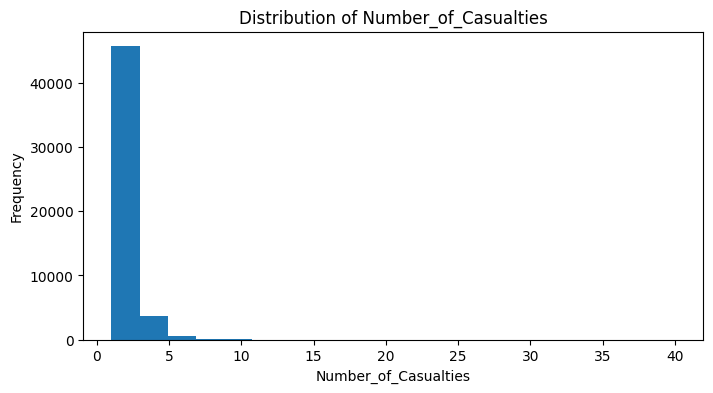

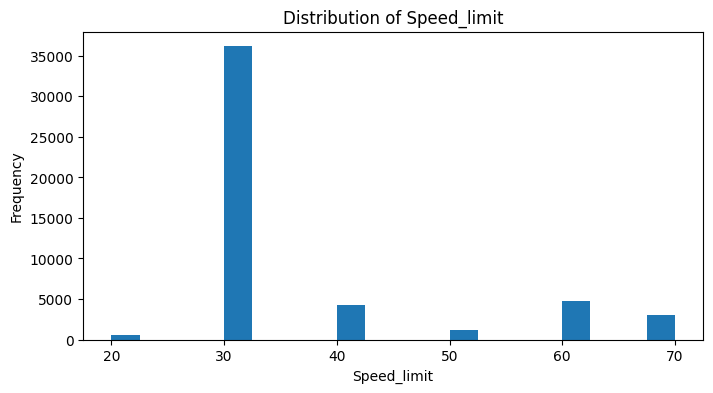

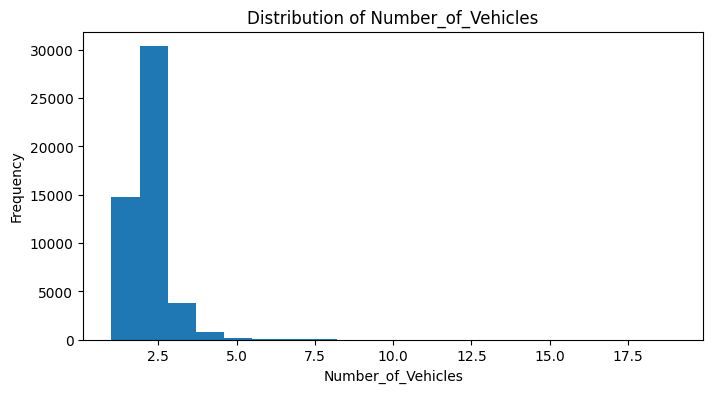

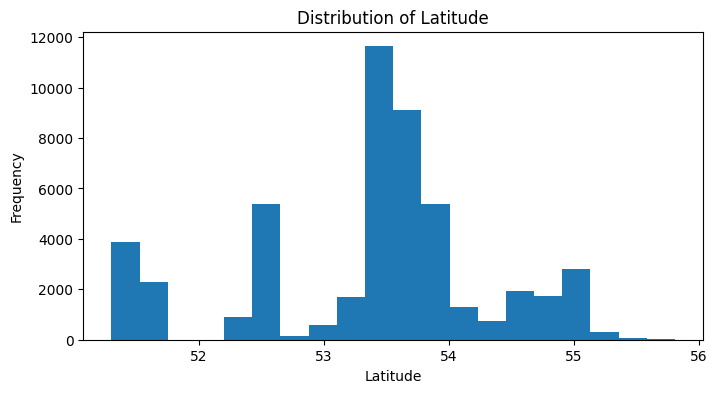

In [ ]:
# Determining the distribution of numerical variables

import matplotlib.pyplot as plt
columns = [
    'Number_of_Casualties',
    'Speed_limit',
    'Number_of_Vehicles',
    'Latitude'
]

for col in columns:
    plt.figure(figsize=(8, 4))
    plt.hist(data[col].dropna(), bins=20)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()

In [ ]:
# Checking the skewness

columns = [
    'Number_of_Casualties',
    'Speed_limit',
    'Number_of_Vehicles',
    'Latitude'
]

for col in columns:
    print(col, ":", data[col].skew())

Number_of_Casualties : 5.643480031143052
Speed_limit : 1.6464519061674476
Number_of_Vehicles : 2.1903362575816487
Latitude : -0.4834790753953879


In [ ]:
Detecting the outliers present in all numerical values
numerical_cols = [
    'Number_of_Casualties',
    'Speed_limit',
    'Number_of_Vehicles',
    'Latitude']

for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = data[
        (data[col] < lower_limit) |
        (data[col] > upper_limit)
    ]

    print(f"\n{col}")
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)
    print("Number of outliers:", len(outliers))


Number_of_Casualties
Lower limit: -0.5
Upper limit: 3.5
Number of outliers: 1695

Speed_limit
Lower limit: 15.0
Upper limit: 55.0
Number of outliers: 7854

Number_of_Vehicles
Lower limit: -0.5
Upper limit: 3.5
Number of outliers: 1054

Latitude
Lower limit: 51.035000000000004
Upper limit: 55.475
Number of outliers: 65


In [ ]:
# Define the IQR limits
limits = {
    'Number_of_Casualties': (-0.5, 3.5),
    'Speed_limit': (15, 55),
    'Number_of_Vehicles': (-0.5, 3.5),
    'Latitude': (51.035, 55.475)
}

# Display outlier values for each column
for col, (lower, upper) in limits.items():

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(f"\nColumn: {col}")
    print("Outlier values:")
    print(outliers[col].value_counts())


Column: Number_of_Casualties
Outlier values:
Number_of_Casualties
4     1072
5      362
6      144
7       58
8       21
9       15
10       5
11       4
12       4
17       3
13       2
40       1
24       1
16       1
26       1
14       1
Name: count, dtype: int64

Column: Speed_limit
Outlier values:
Speed_limit
60    4810
70    3044
Name: count, dtype: int64

Column: Number_of_Vehicles
Outlier values:
Number_of_Vehicles
4     782
5     173
6      44
7      21
8      16
9       5
11      4
13      3
10      3
12      1
19      1
14      1
Name: count, dtype: int64

Column: Latitude
Outlier values:
Latitude
55.76    9
55.77    5
55.58    4
55.68    3
55.55    3
55.71    3
55.60    3
55.64    3
55.56    3
55.57    3
55.54    3
55.61    2
55.78    2
55.67    2
55.53    2
55.62    2
55.72    2
55.48    1
55.65    1
55.75    1
55.73    1
55.80    1
55.70    1
55.52    1
55.81    1
55.74    1
55.50    1
55.59    1
Name: count, dtype: int64


#  Outlier Analysis Specifications

**Number_of_Casualties:** 1,695 outliers were identified. Values ranged from 4 to 40 casualties. These values were considered genuine accident observations and retained.

 **Speed_limit:** 7,854 outliers were identified, consisting of speed limits of 60 and 70. These were considered valid speed-limit values and retained.

 **Number_of_Vehicles:** 1,054 outliers were identified. Values ranged from 4 to 19 vehicles. These were considered genuine multi-vehicle accident observations and retained.

 **Latitude:** 65 outliers were identified, with values ranging approximately from 55.48 to 55.81. These were considered genuine geographical observations and retained.

 **Overall conclusion:** The IQR method identified statistically unusual values in the above columns. Based on the investigation, the identified outliers were retained, as they were considered genuine observations rather than data errors. No outliers were removed solely based on statistical thresholds.


#  EXPLORATORY DATA ANALYSIS

In [ ]:
cat_cols=data.select_dtypes(include='object')

In [ ]:
cat_cols.nunique()

,0
Accident Date,1066
Junction_Control,7
Junction_Detail,9
Accident_Severity,4
Light_Conditions,5
Local_Authority_(District),7
Police_Force,15
Road_Surface_Conditions,5
Road_Type,6
Urban_or_Rural_Area,2


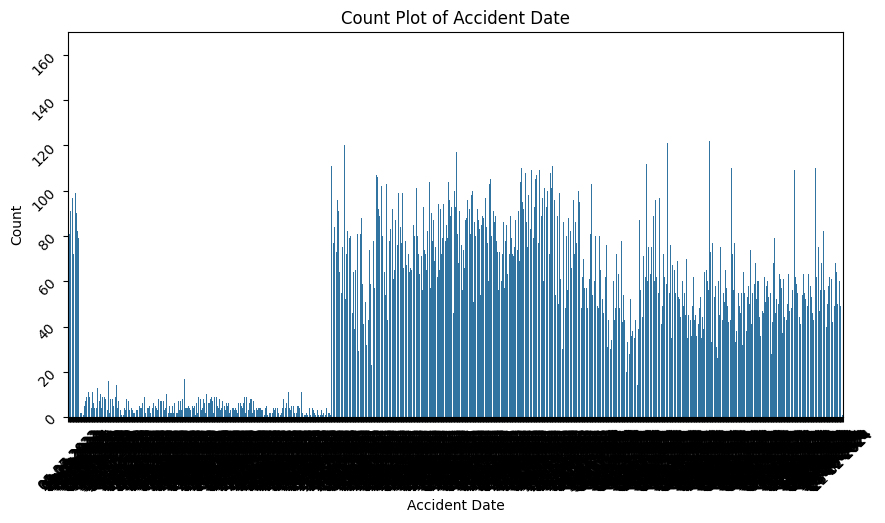

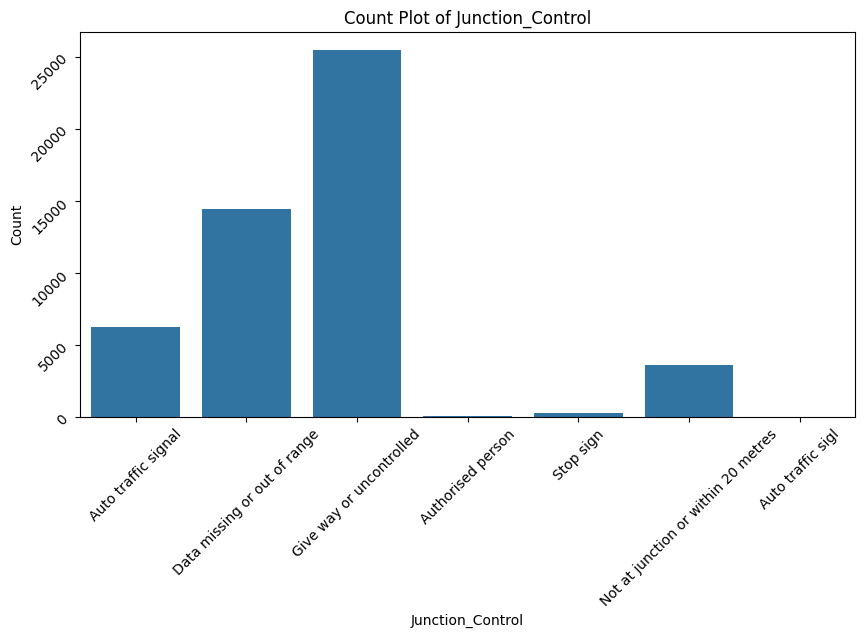

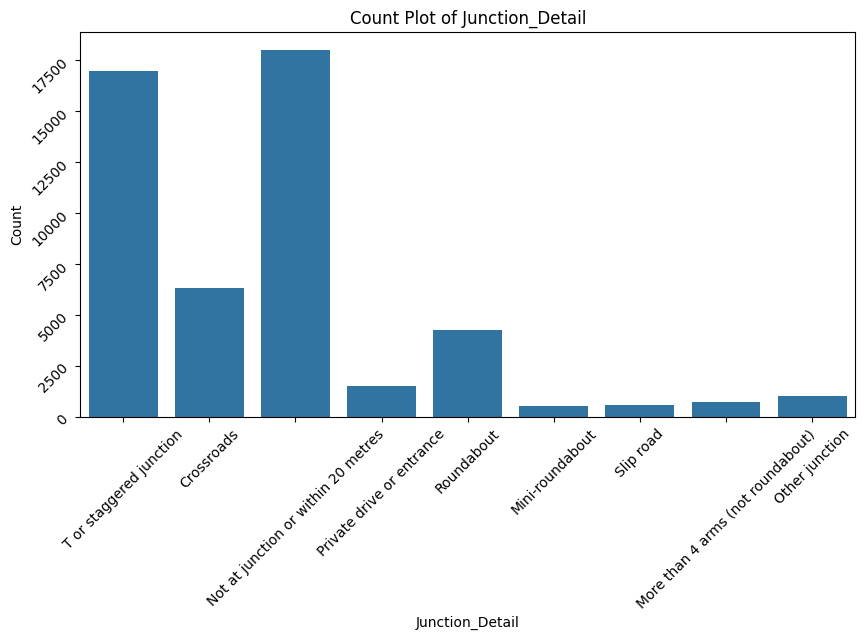

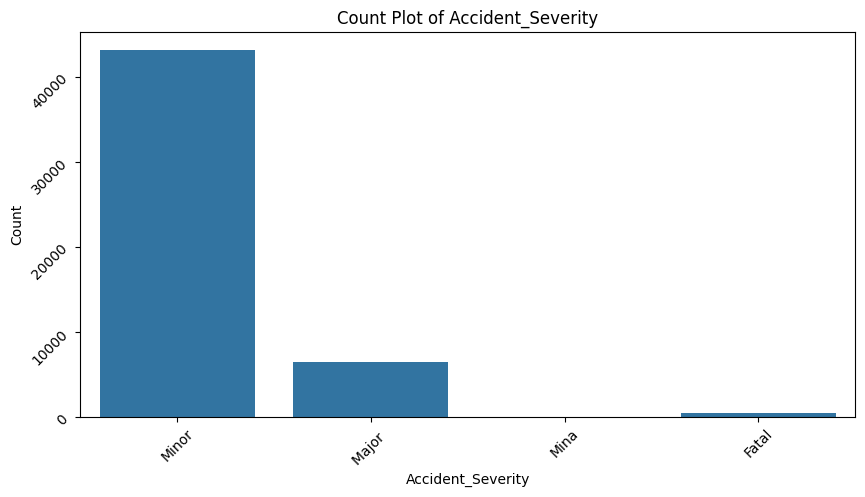

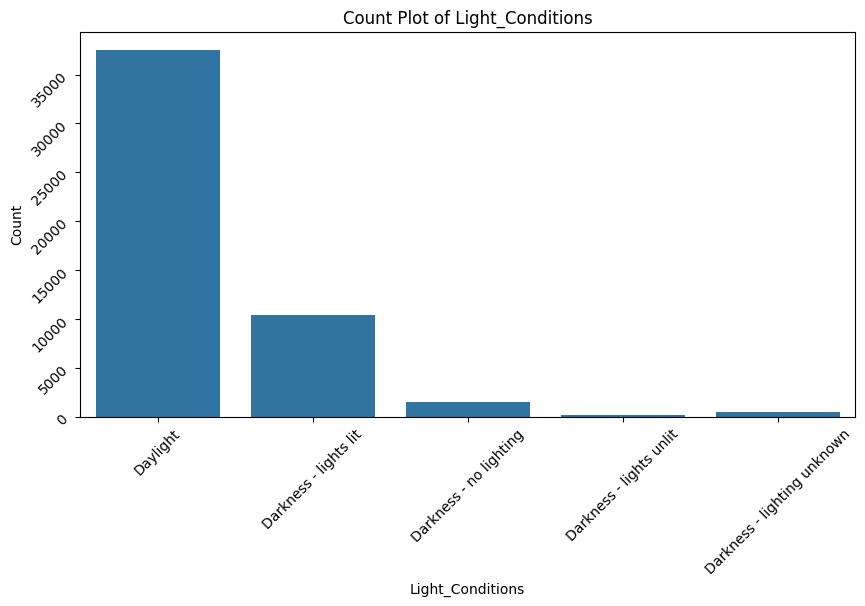

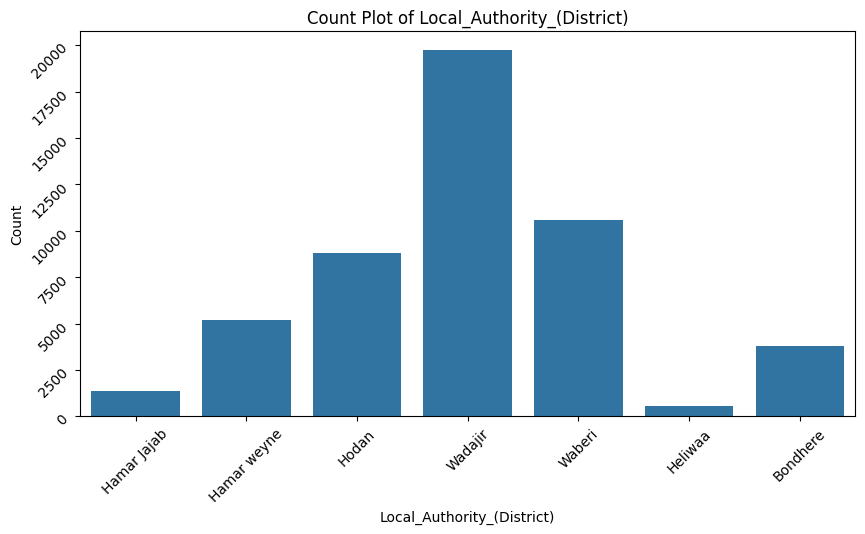

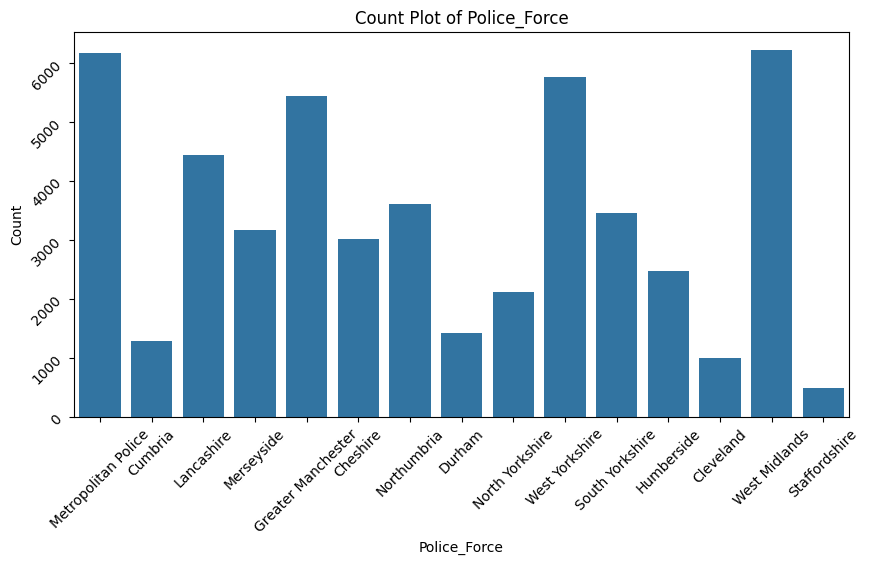

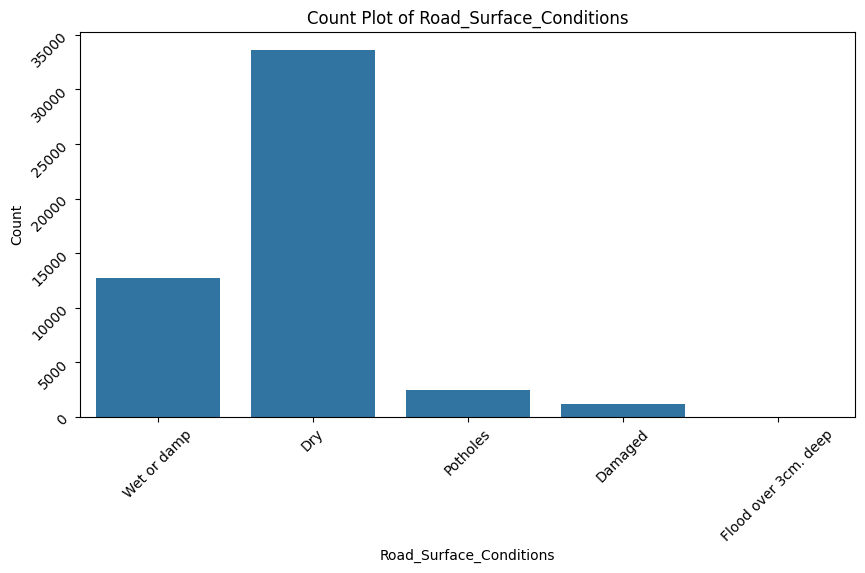

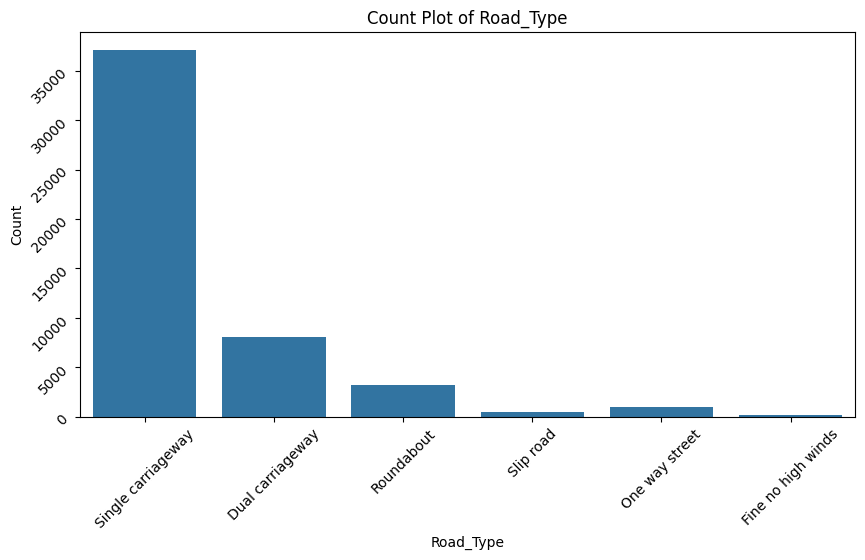

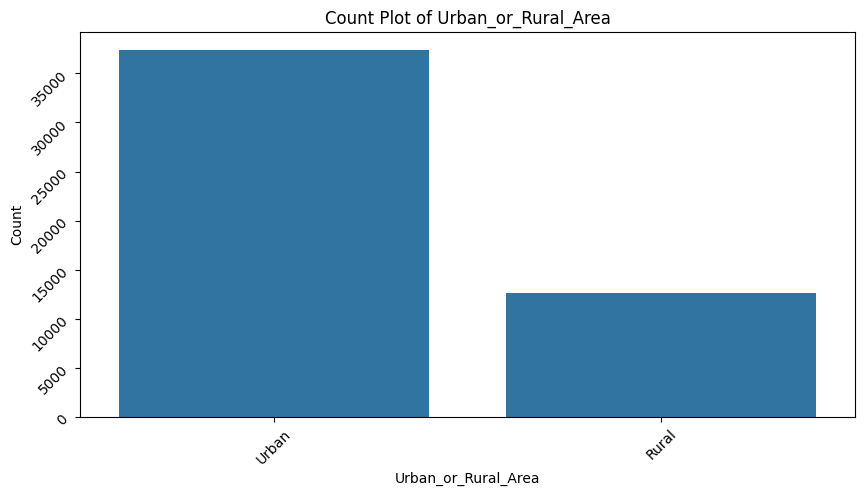

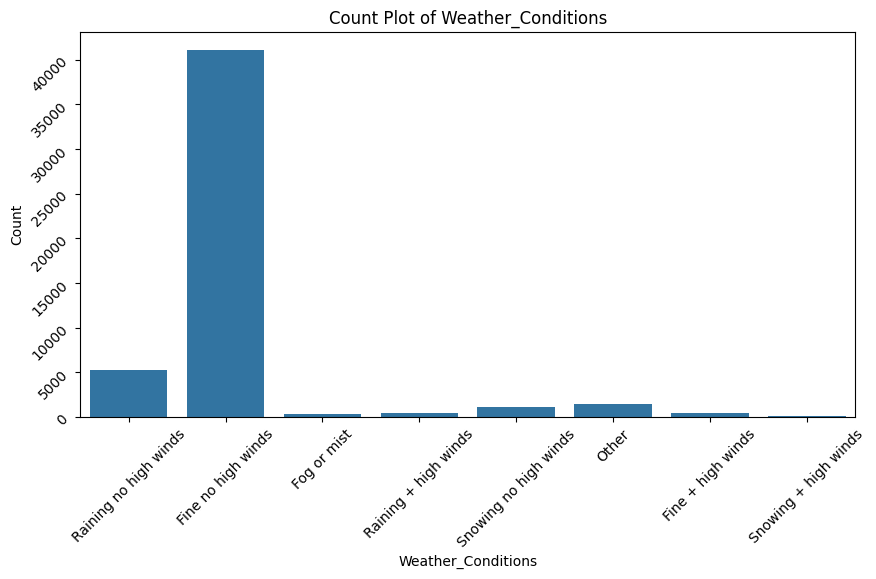

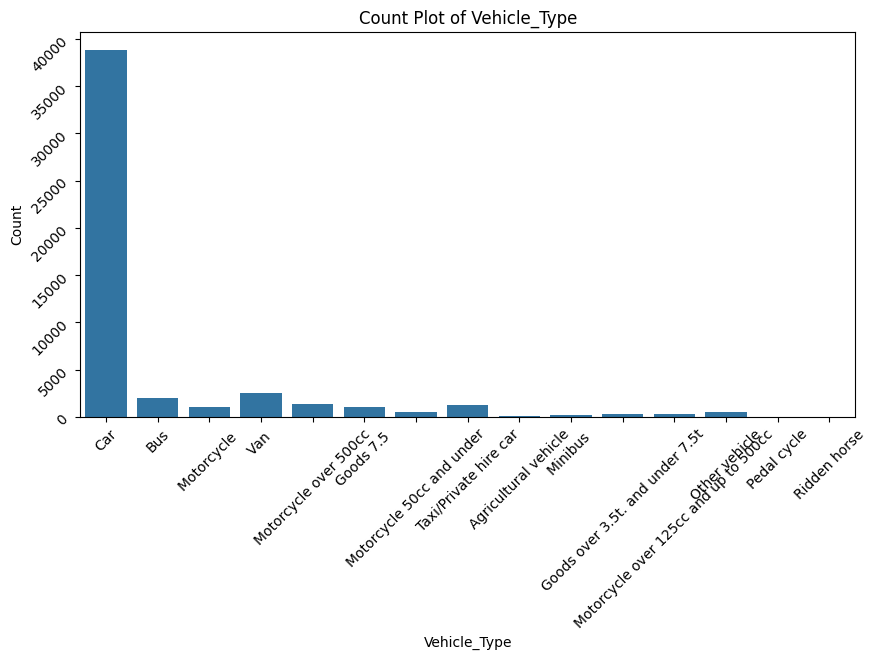

In [ ]:
# Analyzed all categorial columns

categorical_cols = data.select_dtypes(include='object').columns

for col in categorical_cols:

    plt.figure(figsize=(10, 5))

    sns.countplot(data=data, x=col)

    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    plt.xticks(rotation=45)
    plt.yticks(rotation=45, ha='right')

    plt.show()

**Insight**

The distribution is highly uneven, with accidents concentrated mainly in “Give way or uncontrolled” and “Data missing or out of range.” Before drawing conclusions about the effect of junction control on accidents, the missing/out-of-range records should be examined because they represent a significant portion of the dataset.

In [ ]:
data.select_dtypes(include='object').columns

Index(['Accident Date', 'Junction_Control', 'Junction_Detail',
       'Accident_Severity', 'Light_Conditions', 'Local_Authority_(District)',
       'Police_Force', 'Road_Surface_Conditions', 'Road_Type',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type'],
      dtype='object')

In [ ]:
data.select_dtypes(include=['int64','float64']).columns

Index(['Accident_Index', 'Latitude', 'Longitude', 'Number_of_Casualties',
       'Number_of_Vehicles', 'Speed_limit', 'Hour'],
      dtype='object')

In [ ]:
data['Hour']=data['Hour'].astype(int)

In [ ]:
data.select_dtypes(include='object')

,Accident Date,Junction_Control,Junction_Detail,Accident_Severity,Light_Conditions,Local_Authority_(District),Police_Force,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,01-10-2022,Auto traffic signal,T or staggered junction,Minor,Daylight,Hamar Jajab,Metropolitan Police,Wet or damp,Single carriageway,Urban,Raining no high winds,Car
1,06-07-2022,Auto traffic signal,Crossroads,Minor,Darkness - lights lit,Hamar Jajab,Metropolitan Police,Dry,Single carriageway,Urban,Fine no high winds,Car
2,08-07-2022,Auto traffic signal,Crossroads,Minor,Daylight,Hamar Jajab,Metropolitan Police,Dry,Dual carriageway,Urban,Fine no high winds,Bus
3,21-09-2022,Auto traffic signal,T or staggered junction,Major,Daylight,Hamar Jajab,Metropolitan Police,Dry,Single carriageway,Urban,Fine no high winds,Bus
4,03-10-2022,Data missing or out of range,Not at junction or within 20 metres,Minor,Darkness - lights lit,Hamar Jajab,Metropolitan Police,Wet or damp,Dual carriageway,Urban,Raining no high winds,Car
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,02-03-2024,Data missing or out of range,Not at junction or within 20 metres,Minor,Daylight,Waberi,Staffordshire,Dry,Dual carriageway,Urban,Fine no high winds,Car
49996,26-02-2024,Give way or uncontrolled,Private drive or entrance,Minor,Daylight,Waberi,Staffordshire,Wet or damp,Single carriageway,Rural,Fine no high winds,Car
49997,28-02-2024,Give way or uncontrolled,T or staggered junction,Minor,Darkness - lights lit,Waberi,Staffordshire,Dry,Single carriageway,Rural,Fine no high winds,Car
49998,22-02-2024,Give way or uncontrolled,T or staggered junction,Minor,Darkness - lights lit,Waberi,Staffordshire,Dry,Single carriageway,Rural,Fine no high winds,Car


In [ ]:
# Checking unique variables in each columns
categorical_cols = data.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"{col}: {data[col].nunique()}")

Accident Date: 1066
Junction_Control: 7
Junction_Detail: 9
Accident_Severity: 4
Light_Conditions: 5
Local_Authority_(District): 7
Police_Force: 15
Road_Surface_Conditions: 5
Road_Type: 6
Urban_or_Rural_Area: 2
Weather_Conditions: 8
Vehicle_Type: 15


In [ ]:
data['Accident Date'] = pd.to_datetime(data['Accident Date'], format='%d-%m-%Y')
data['Accident Date'].dtype

dtype('<M8[ns]')

In [ ]:
categorical_cols = data.select_dtypes(include='object').columns
print(categorical_cols )

Index(['Junction_Control', 'Junction_Detail', 'Accident_Severity',
       'Light_Conditions', 'Local_Authority_(District)', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Urban_or_Rural_Area',
       'Weather_Conditions', 'Vehicle_Type'],
      dtype='object')


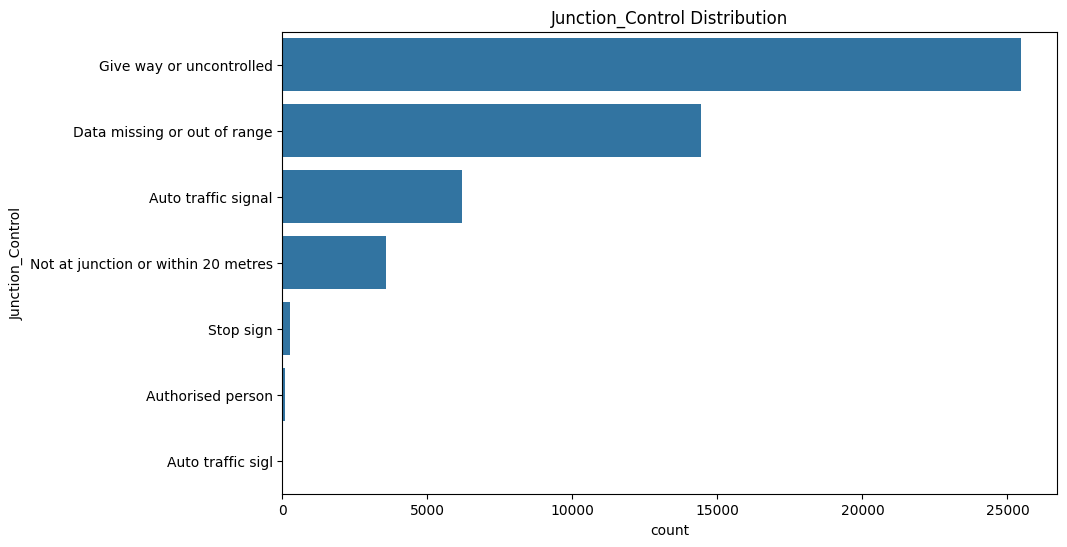

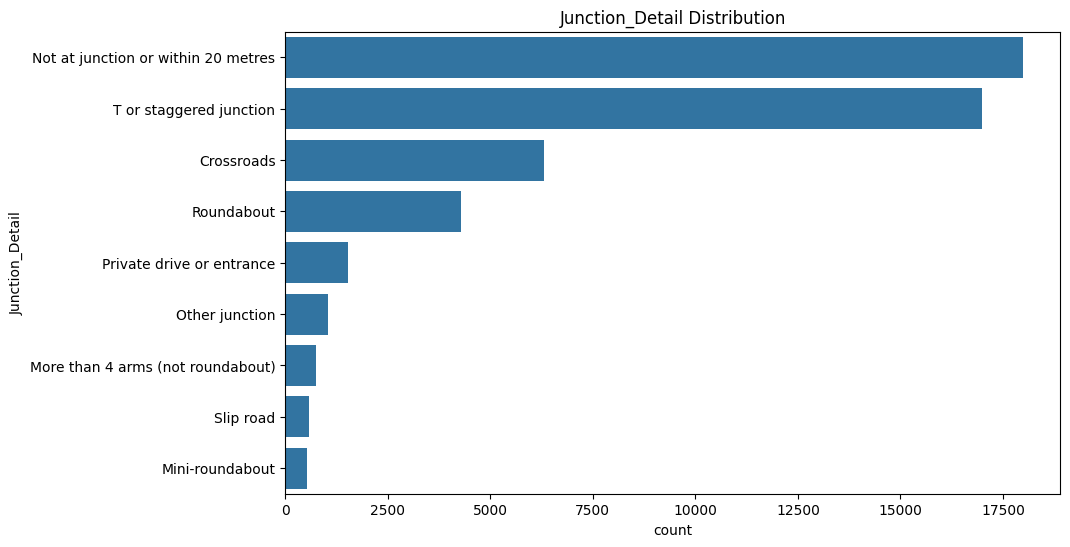

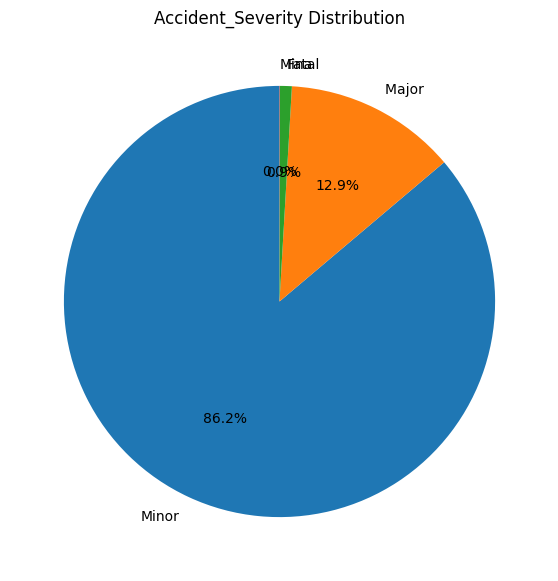

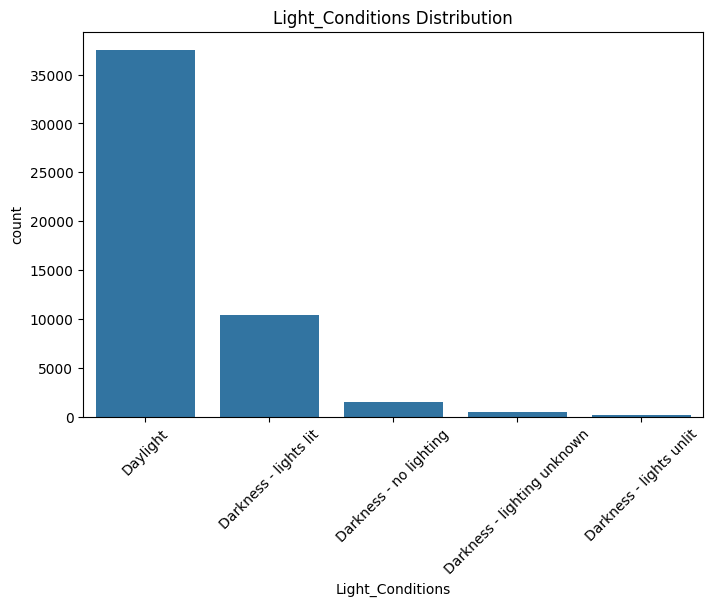

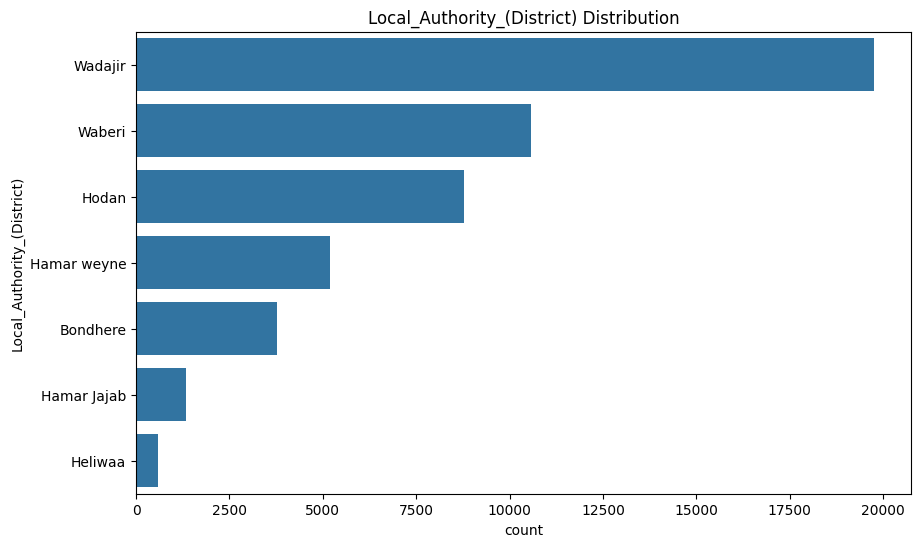

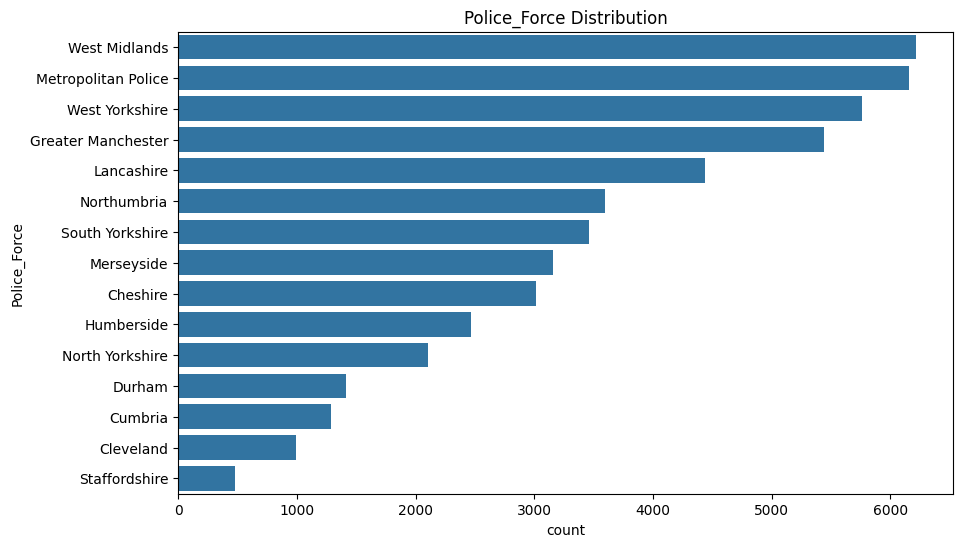

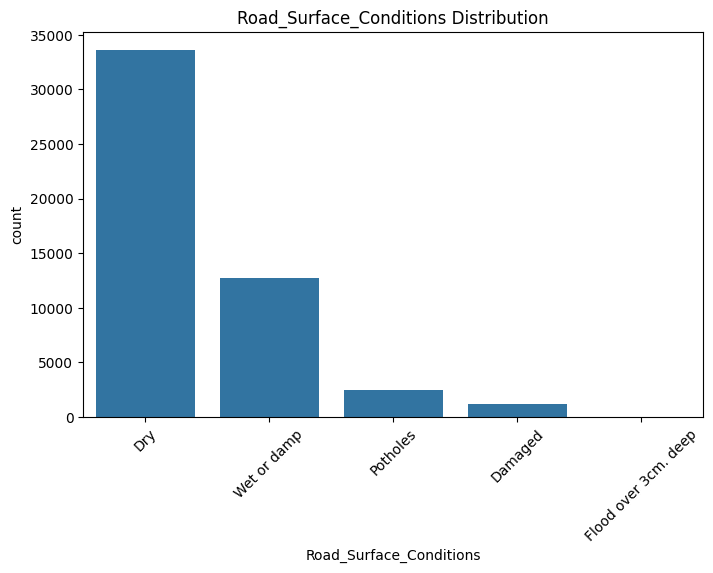

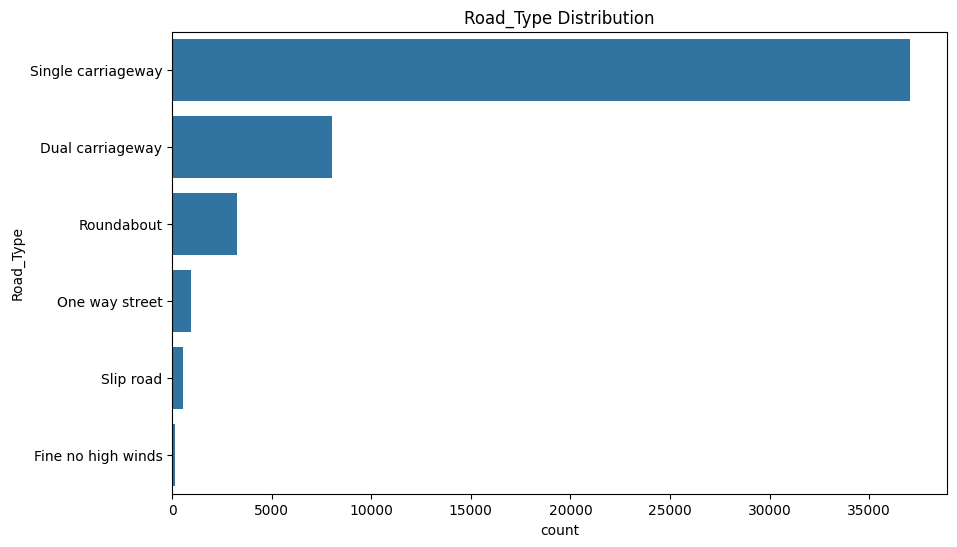

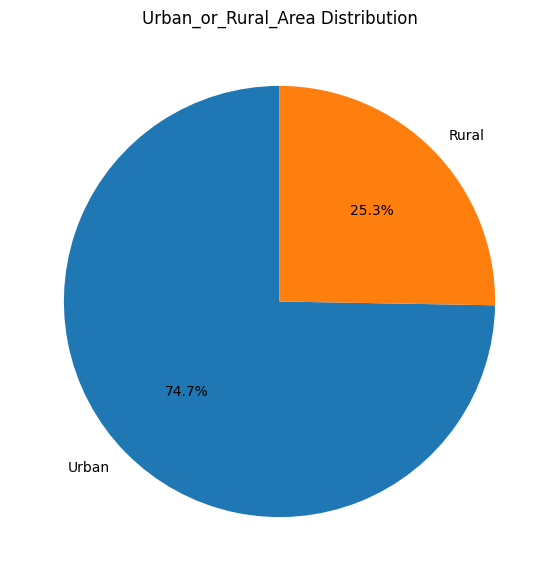

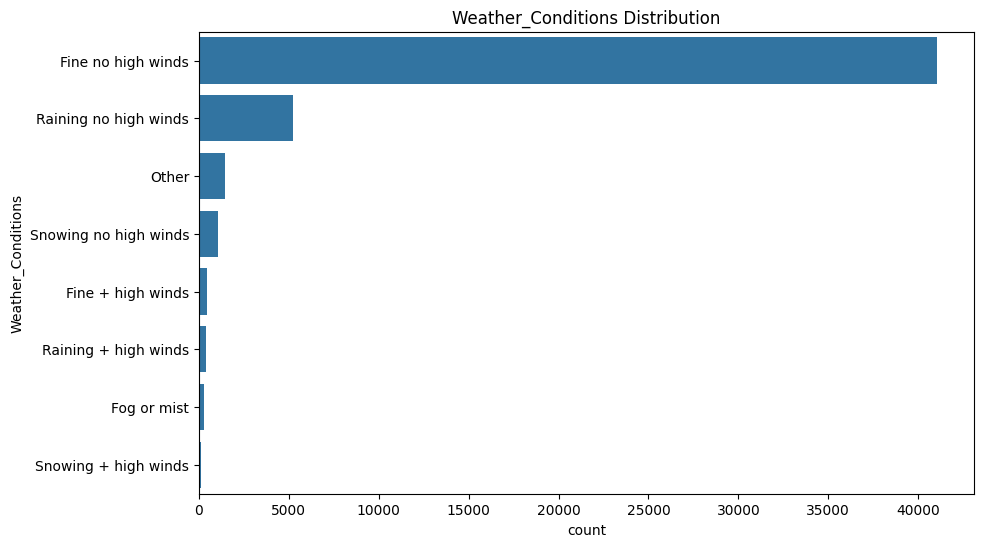

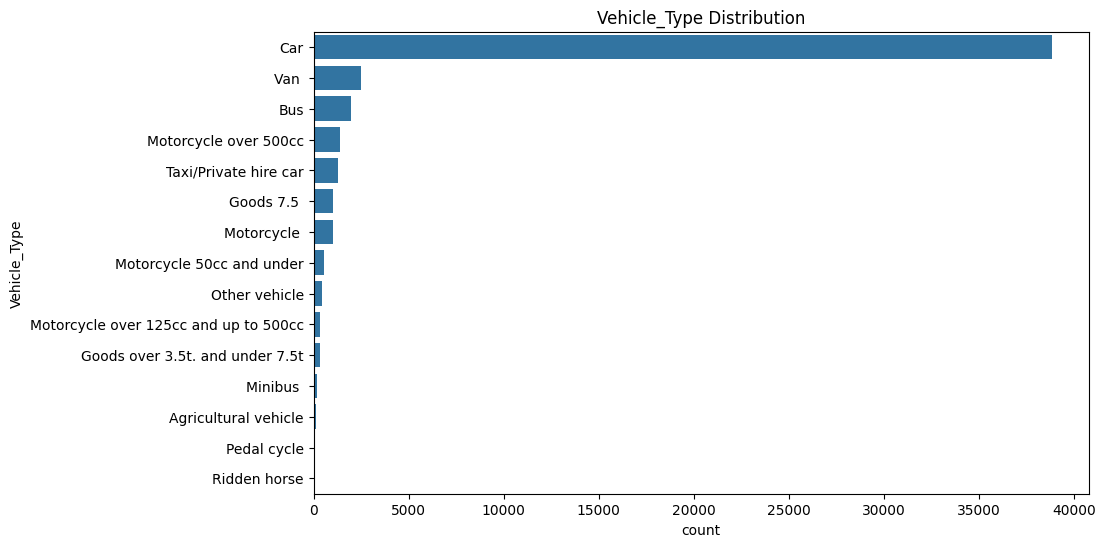

In [ ]:
# Analyzed all categorical variables

categorical_cols = data.select_dtypes(include='object').columns

for col in categorical_cols:

    unique_count = data[col].nunique()
    counts = data[col].value_counts()

    # Less than 5 unique values → Pie chart
    if unique_count < 5:

        plt.figure(figsize=(7, 7))

        plt.pie(
            counts,
            labels=counts.index,
            autopct='%1.1f%%',
            startangle=90
        )

        plt.title(f'{col} Distribution')
        plt.show()

    # Exactly 5 unique values → Column chart
    elif unique_count == 5:

        plt.figure(figsize=(8, 5))

        sns.countplot(
            data=data,
            x=col,
            order=counts.index
        )

        plt.title(f'{col} Distribution')
        plt.xticks(rotation=45)
        plt.show()

    # More than 5 unique values → Horizontal bar chart
    else:

        plt.figure(figsize=(10, 6))

        sns.countplot(
            data=data,
            y=col,
            order=counts.index
        )

        plt.title(f'{col} Distribution')
        plt.show()

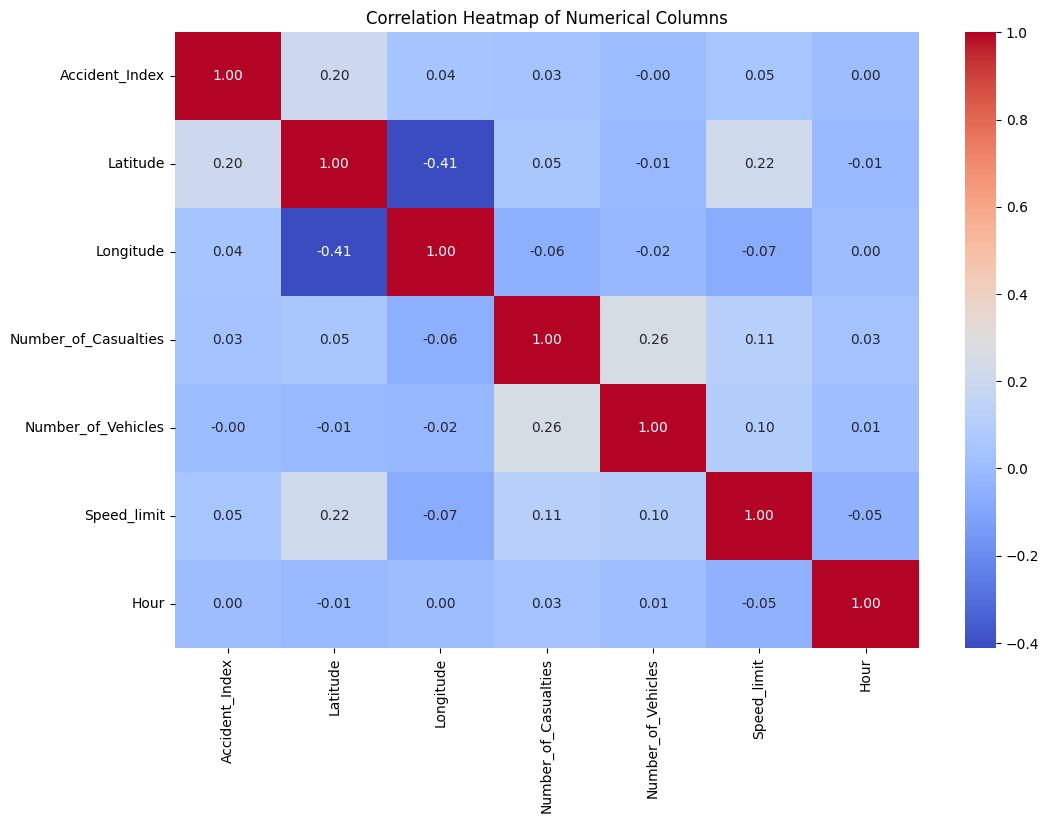

In [ ]:
numerical_cols = data.select_dtypes(include='number').columns
plt.figure(figsize=(12, 8))

sns.heatmap(
    data[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

**Insight**

The variables appear largely independent in terms of linear correlation, with Number_of_Casualties–Number_of_Vehicles and Latitude–Longitude being the most noticeable relationships.

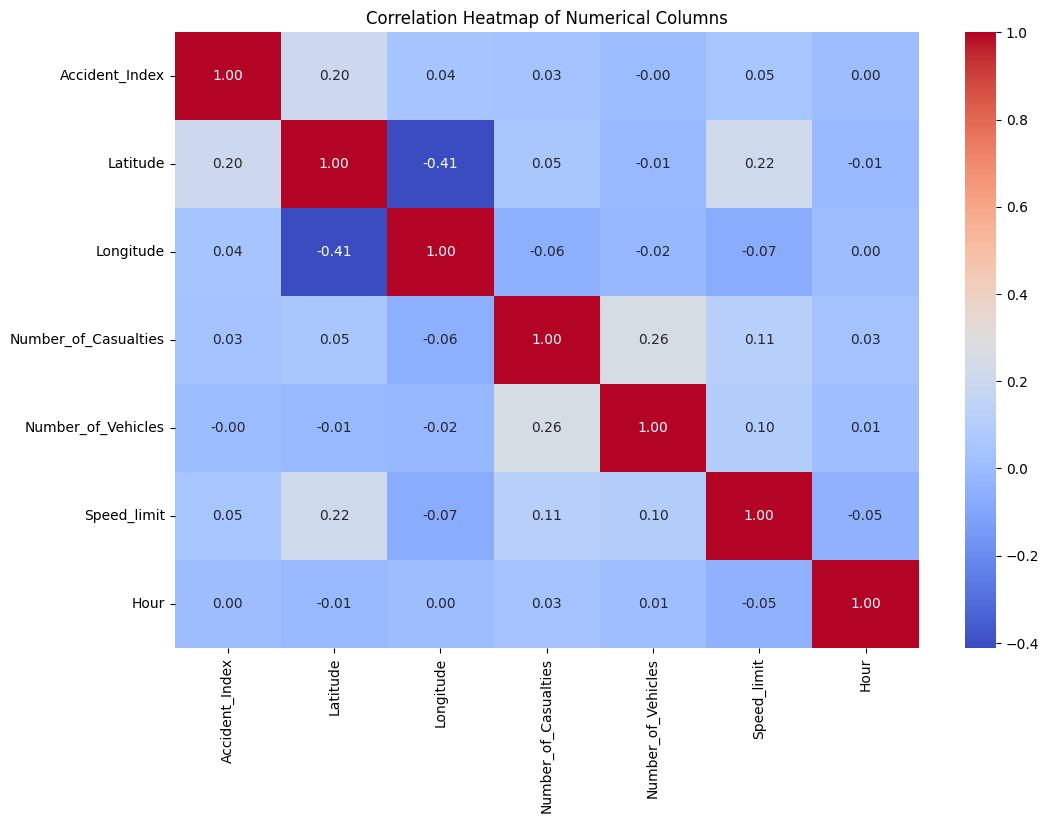

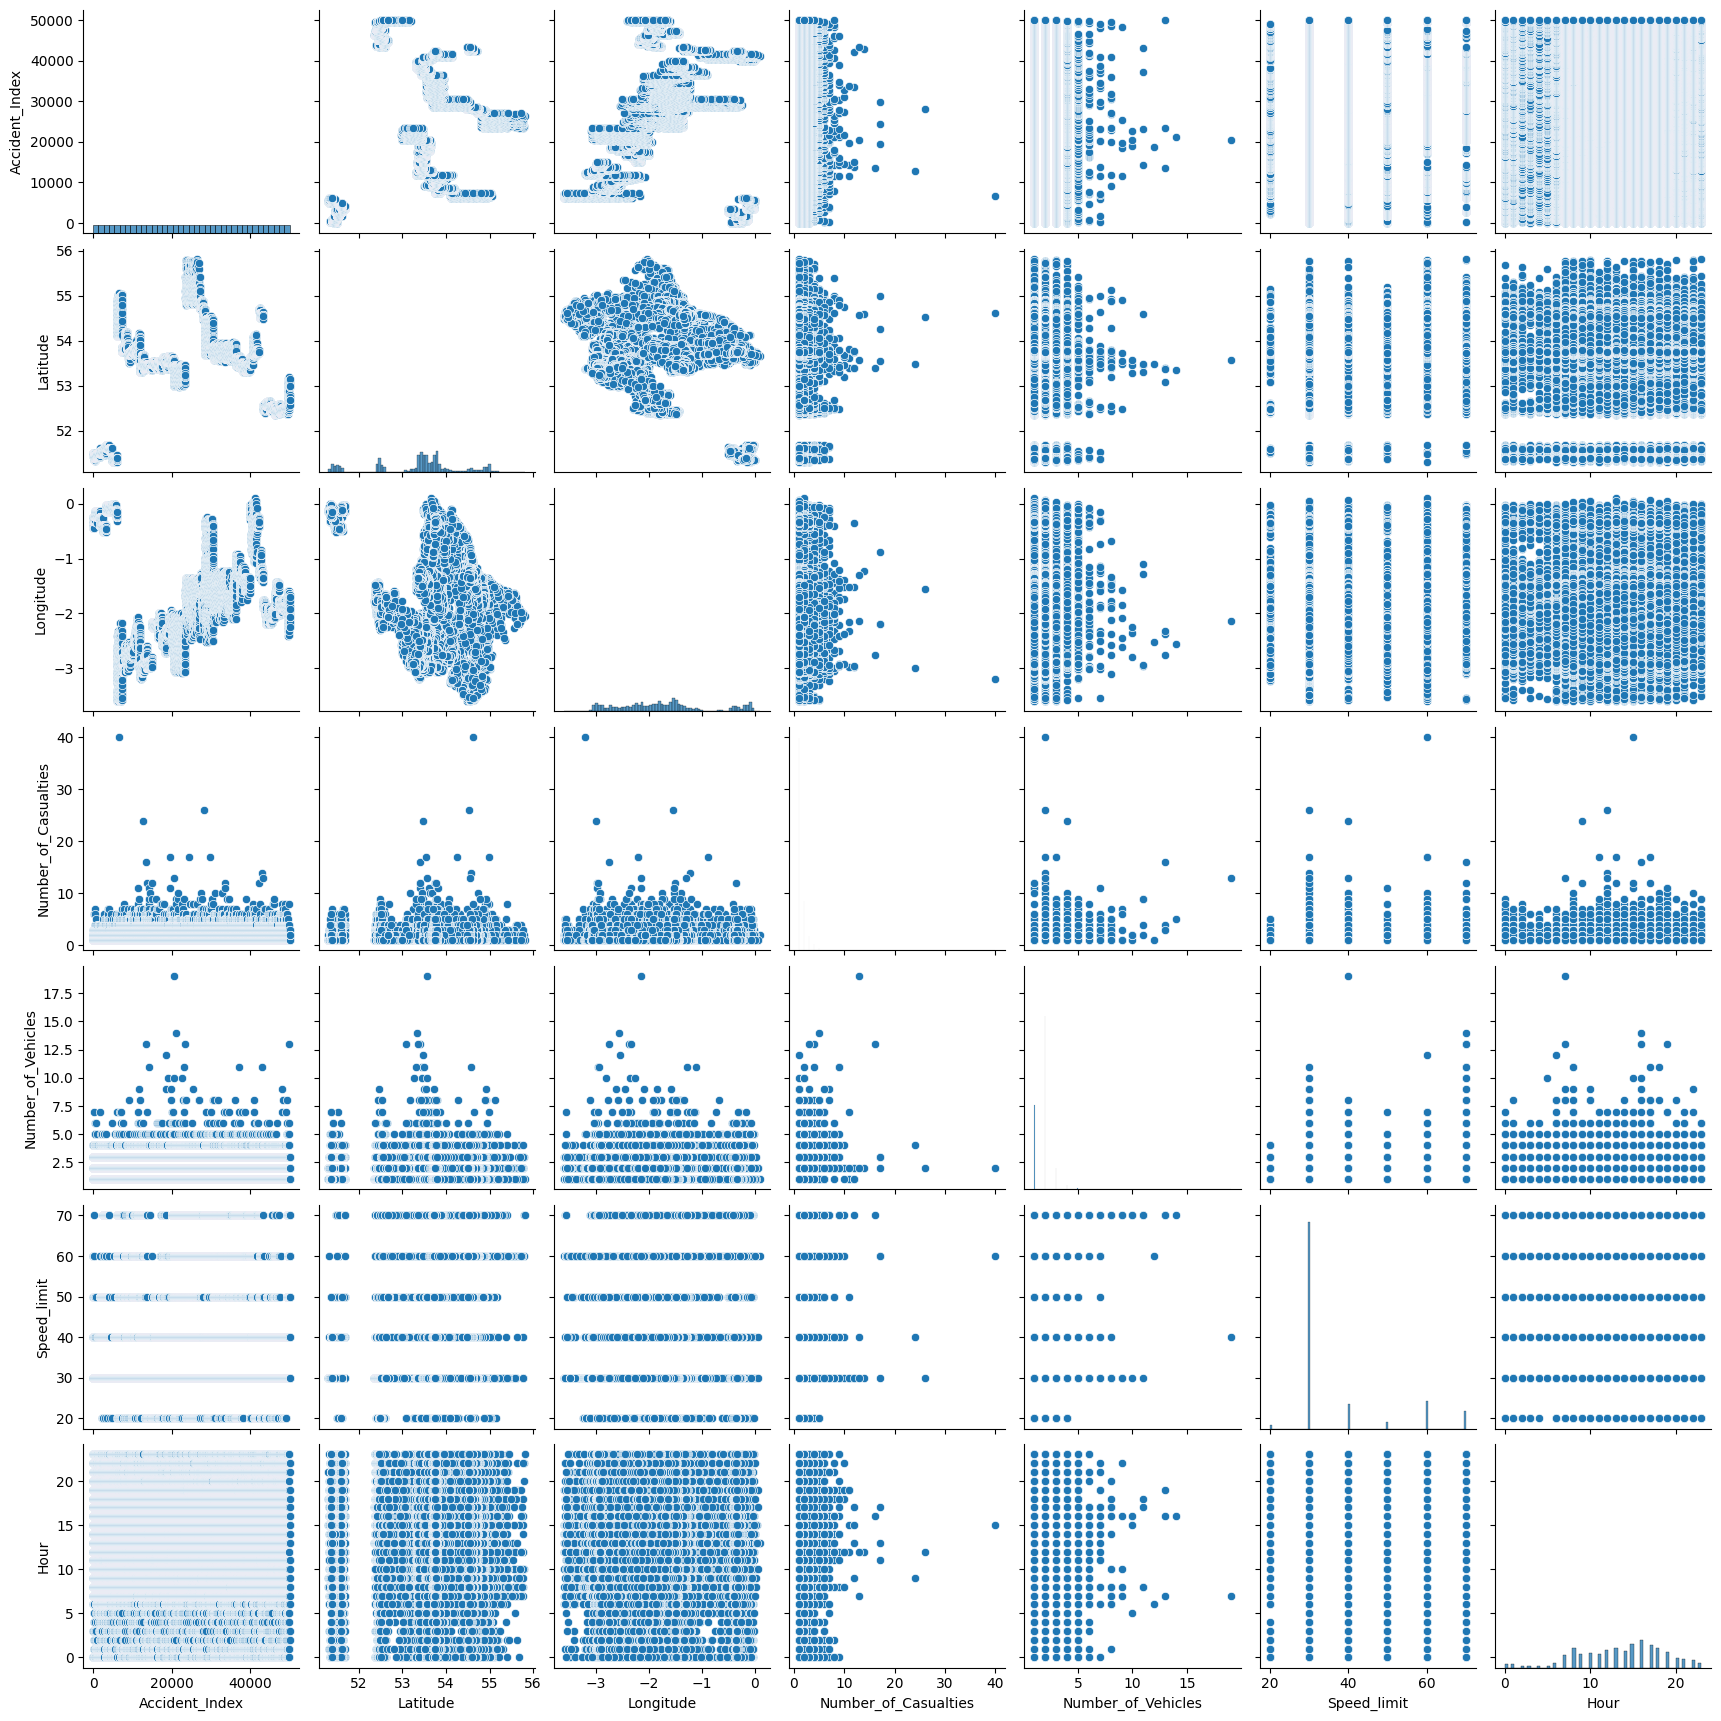

In [ ]:
# Select numerical columns
numerical_cols = data.select_dtypes(include='number').columns

# Correlation Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    data[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Columns')
plt.show()


# Pairplot
sns.pairplot(data[numerical_cols])

plt.show()

**Insight**

Accident occurrence is strongly influenced by location and time patterns, while casualty severity varies considerably between accidents. The relatively small number of accidents with very high casualties should be highlighted separately as potential high-severity accident cases.

In [ ]:
data.to_csv('cleaned_Accident.csv', index=False)

In [ ]:
from google.colab import files

files.download('cleaned_Accident.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>